# MLTS — Lecture 1 Practice
## Time Series Fundamentals

This notebook accompanies **Lecture 1** of the MLTS course summary. It walks through
the foundational concepts of time series analysis with runnable examples and ends with
three exercises (solutions included).

**You will learn how to:**
1. Generate and visualise canonical time series (deterministic, AR(1), random walk, Poisson events).
2. Distinguish regular vs irregular sampling, univariate vs multivariate.
3. Sample a *stochastic process* and tell the difference between **time average** and **ensemble average**.
4. Test for **stationarity** visually and with the ADF / KPSS hypothesis tests.
5. Compute **autocovariance** and **ACF** by hand and with `statsmodels`.
6. Empirically demonstrate **ergodicity** — and a case where it fails.
7. Verify the **Central Limit Theorem** for an M-dependent process.

**Prerequisites:** `numpy`, `scipy`, `matplotlib`, `statsmodels`. Install with:
```bash
pip install numpy scipy matplotlib statsmodels
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Reproducibility
rng = np.random.default_rng(seed=42)

# Make plots look consistent
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1 · What is a time series?

A time series is a sequence of observations indexed by time:
$$S = \{s_1, s_2, \dots, s_T\}, \quad s_i \in \mathbb{R}^d$$

Below we generate four canonical examples that we will keep using throughout this notebook
and the rest of the course.

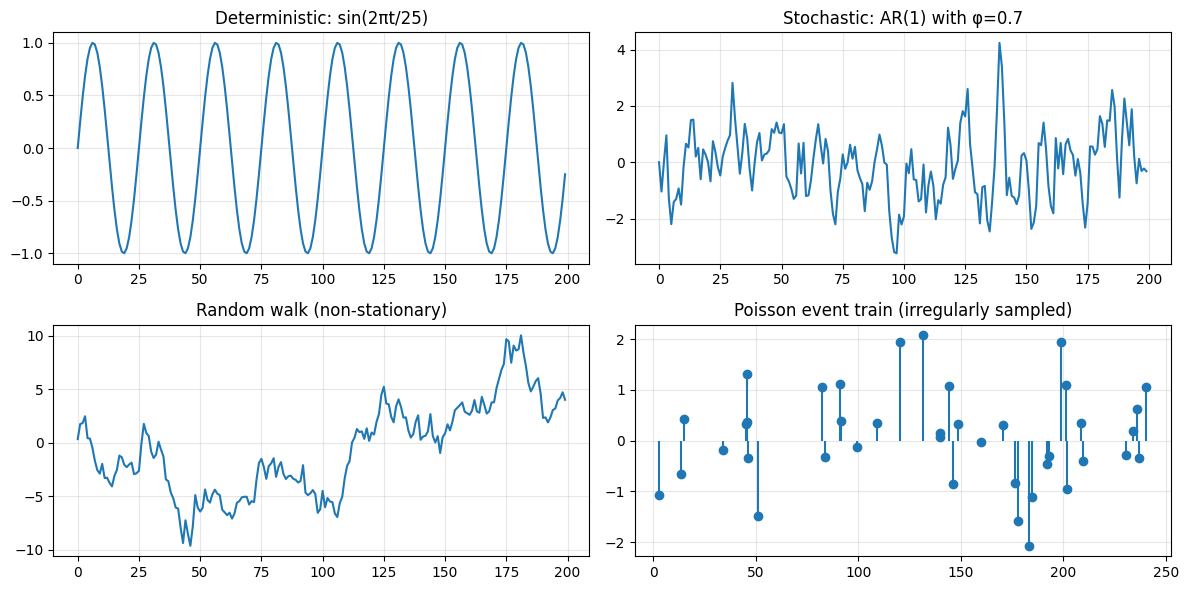

In [2]:
T = 200
t = np.arange(T)

# (a) Deterministic periodic — sin(x) is *predictable* and *periodic*
det_series = np.sin(2 * np.pi * t / 25)

# (b) AR(1): s_t = phi * s_{t-1} + eps_t  (stationary if |phi| < 1)
phi = 0.7
ar1 = np.zeros(T)
eps = rng.normal(scale=1.0, size=T)
for k in range(1, T):
    ar1[k] = phi * ar1[k-1] + eps[k]

# (c) Random walk: s_t = s_{t-1} + eps_t  (NOT stationary — variance grows with t)
rw = np.cumsum(rng.normal(scale=1.0, size=T))

# (d) Poisson event train (irregular sampling — observations *occur* at random times)
event_times = np.cumsum(rng.exponential(scale=5.0, size=40))
event_marks = rng.normal(loc=0, scale=1, size=40)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0,0].plot(t, det_series); axes[0,0].set_title('Deterministic: sin(2πt/25)')
axes[0,1].plot(t, ar1);        axes[0,1].set_title('Stochastic: AR(1) with φ=0.7')
axes[1,0].plot(t, rw);         axes[1,0].set_title('Random walk (non-stationary)')
axes[1,1].stem(event_times, event_marks, basefmt=' ')
axes[1,1].set_title('Poisson event train (irregularly sampled)')
plt.tight_layout(); plt.show()


**Read the plots:**
- The sine is *deterministic*: identical every time you generate it (no `rng` call).
- The AR(1) is *stochastic but stationary* — you'd get a different realisation each run, but the statistics are stable.
- The random walk's spread visibly grows over time — it is *non-stationary*.
- The Poisson series has no fixed sampling rate; you only know the **(time, value)** pairs.


## 2 · Regular vs irregular sampling, univariate vs multivariate

| Type | Definition | Example |
|------|------------|---------|
| Regularly sampled | Δt = const | Hourly weather log |
| Irregularly sampled | Δt varies | Stock trades, ECG heartbeats |
| Univariate (d=1) | One channel per time step | Daily temperature |
| Multivariate (d>1) | Several channels per step | Tri-axial accelerometer (x, y, z) |


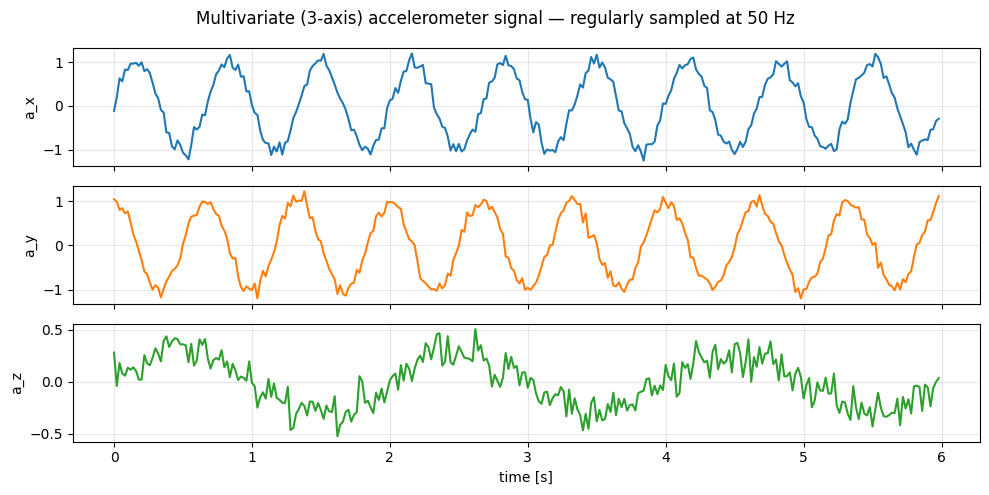

In [3]:
# Multivariate example: 3-axis accelerometer simulation
T = 300
t = np.arange(T) / 50.0  # 50 Hz sampling
accel = np.column_stack([
    np.sin(2*np.pi*1.5*t) + rng.normal(0, 0.1, T),  # x: 1.5 Hz
    np.cos(2*np.pi*1.5*t) + rng.normal(0, 0.1, T),  # y: 1.5 Hz, phase shifted
    0.3*np.sin(2*np.pi*0.5*t) + rng.normal(0, 0.1, T),  # z: slow drift
])

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 5))
for i, label in enumerate(['x', 'y', 'z']):
    axes[i].plot(t, accel[:, i], color=f'C{i}')
    axes[i].set_ylabel(f'a_{label}')
axes[-1].set_xlabel('time [s]')
plt.suptitle('Multivariate (3-axis) accelerometer signal — regularly sampled at 50 Hz')
plt.tight_layout(); plt.show()


## 3 · Stochastic processes — ensemble vs time average

A stochastic process is a *family* of random variables $\{X_t\}_{t \in T}$. A time series
is **one realisation** of that process.

If we had a "battery of N computers" each generating its own AR(1), at any time $t$
we would see N samples $\{x_t^{(1)}, \dots, x_t^{(N)}\}$ — these are samples from the
random variable $X_t$.

Two important averages:
- **Ensemble average** at time $t$: $\frac{1}{N}\sum_n x_t^{(n)} \to E[X_t]$
- **Time average** of one realisation: $\frac{1}{T}\sum_t x_t^{(n)} \to ?$

For an *ergodic* process the two coincide.


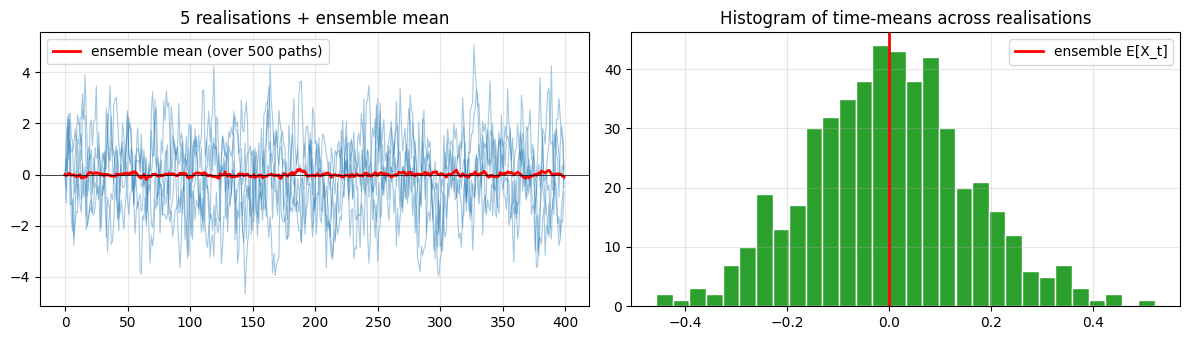

E[X_t] (true)              = 0.000
Ensemble mean (avg over t) = -0.0023
Time-mean (mean across N)  = -0.0023


In [4]:
def simulate_ar1(phi, T, noise_scale=1.0, n_realisations=1, rng=None):
    """Generate n_realisations independent AR(1) trajectories, each of length T."""
    rng = rng or np.random.default_rng()
    eps = rng.normal(scale=noise_scale, size=(n_realisations, T))
    x = np.zeros((n_realisations, T))
    for k in range(1, T):
        x[:, k] = phi * x[:, k-1] + eps[:, k]
    return x

# Generate N=500 realisations of an AR(1), T=400
N, T = 500, 400
ensemble = simulate_ar1(phi=0.7, T=T, n_realisations=N, rng=rng)

ensemble_mean_t = ensemble.mean(axis=0)   # length T — ensemble mean at each t
time_mean_n     = ensemble.mean(axis=1)   # length N — time mean for each realisation

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
# Show 5 sample paths
for i in range(5):
    axes[0].plot(ensemble[i], alpha=0.4, color='C0', lw=0.8)
axes[0].plot(ensemble_mean_t, color='red', lw=2, label='ensemble mean (over 500 paths)')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('5 realisations + ensemble mean'); axes[0].legend()

axes[1].hist(time_mean_n, bins=30, color='C2', edgecolor='white')
axes[1].axvline(0, color='red', lw=2, label='ensemble E[X_t]')
axes[1].set_title('Histogram of time-means across realisations'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"E[X_t] (true)              = 0.000")
print(f"Ensemble mean (avg over t) = {ensemble_mean_t.mean():.4f}")
print(f"Time-mean (mean across N)  = {time_mean_n.mean():.4f}")


Both estimators agree, which is consistent with the AR(1)'s ergodicity (it is also stationary).
The histogram on the right shows that *individual* time means scatter around 0 — that's
finite-sample variance, not a violation of ergodicity.


## 4 · Stationarity

A process is **weakly stationary** if both the mean and autocovariance are time-invariant:
$$\mu_t = \mu, \qquad \gamma_t^j = \gamma^j \quad \forall t.$$

We test stationarity two ways: visually (rolling mean / variance) and with hypothesis tests.

**ADF (Augmented Dickey–Fuller):** H₀ = "has a unit root" (non-stationary). Reject ⇒ stationary.
**KPSS:** H₀ = "stationary". Reject ⇒ non-stationary. The two are complementary.


In [5]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')  # KPSS prints a noisy InterpolationWarning

def stationarity_report(series, name):
    adf_p  = adfuller(series, autolag='AIC')[1]
    kpss_p = kpss(series, regression='c', nlags='auto')[1]
    print(f"{name:>14s}  ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  ->  "
          f"{'stationary' if (adf_p < 0.05 and kpss_p > 0.05) else 'NON-stationary'}")

T = 500
ar1_s = simulate_ar1(0.7, T, n_realisations=1, rng=rng).ravel()
rw_s  = np.cumsum(rng.normal(size=T))
trend_s = 0.02 * np.arange(T) + rng.normal(size=T)

stationarity_report(ar1_s, 'AR(1)')
stationarity_report(rw_s,  'random walk')
stationarity_report(trend_s, 'trend + noise')


         AR(1)  ADF p=0.0000  KPSS p=0.1000  ->  stationary
   random walk  ADF p=0.7636  KPSS p=0.0100  ->  NON-stationary
 trend + noise  ADF p=0.8123  KPSS p=0.0100  ->  NON-stationary


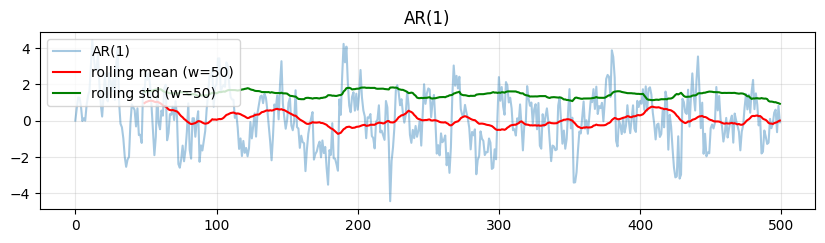

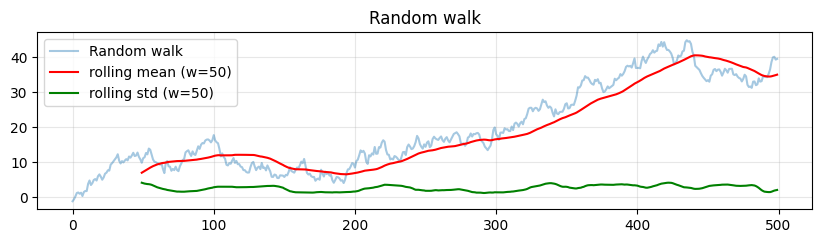

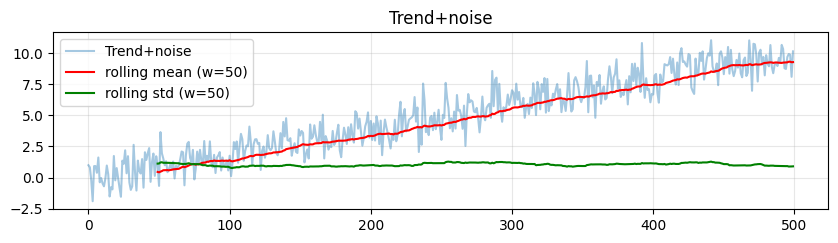

In [6]:
# Visual stationarity check: rolling mean / std

def rolling_stat(x, w, fn):
    out = np.full_like(x, np.nan, dtype=float)
    for i in range(w-1, len(x)):
        out[i] = fn(x[i-w+1:i+1])
    return out

for series, name in [(ar1_s, 'AR(1)'), (rw_s, 'Random walk'), (trend_s, 'Trend+noise')]:
    fig, ax = plt.subplots(figsize=(10, 2.3))
    ax.plot(series, alpha=0.4, label=name)
    ax.plot(rolling_stat(series, 50, np.mean), color='red',   label='rolling mean (w=50)')
    ax.plot(rolling_stat(series, 50, np.std),  color='green', label='rolling std (w=50)')
    ax.legend(loc='upper left'); ax.set_title(name); plt.show()


For **AR(1)** the rolling mean fluctuates around 0 and the rolling std stays roughly constant — both signs of stationarity. For the **random walk** and **trend+noise** series, the rolling mean drifts.


## 5 · Autocovariance and the ACF

The **j-th autocovariance** is
$$\gamma^j = E[(X_t - \mu)(X_{t-j} - \mu)],$$
and the **autocorrelation** (ACF) is the normalised version $\rho^j = \gamma^j / \gamma^0$.

For AR(1) the theoretical ACF is $\rho^j = \phi^j$ — a clean exponential decay. Let's verify.

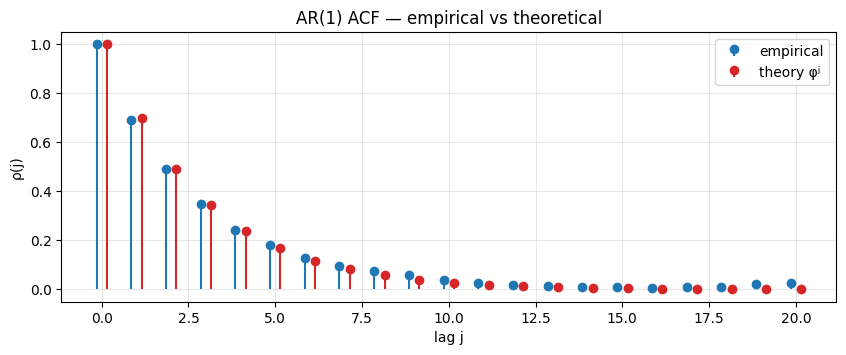

In [7]:
from statsmodels.tsa.stattools import acf

# Long realisation for stable estimate
ar1_long = simulate_ar1(phi=0.7, T=5000, n_realisations=1, rng=rng).ravel()
emp_acf = acf(ar1_long, nlags=20, fft=True)
theo_acf = 0.7 ** np.arange(21)

fig, ax = plt.subplots(figsize=(10, 3.5))
lags = np.arange(21)
ax.stem(lags - 0.15, emp_acf,  linefmt='C0-', markerfmt='C0o', basefmt=' ', label='empirical')
ax.stem(lags + 0.15, theo_acf, linefmt='C3-', markerfmt='C3o', basefmt=' ', label='theory φʲ')
ax.set_xlabel('lag j'); ax.set_ylabel('ρ(j)'); ax.legend()
ax.set_title('AR(1) ACF — empirical vs theoretical')
plt.show()


## 6 · A non-ergodic example

A process can be stationary but not ergodic. Classic textbook example: **a random offset
that is fixed at t=0 and then never changes.**

Each realisation gets its own constant offset $\mu^{(i)} \sim \mathcal{N}(0, \lambda^2)$, then:
$$x_t^{(i)} = \mu^{(i)} + \eta_t^{(i)}, \quad \eta_t \sim \mathcal{N}(0, \sigma^2).$$
The ensemble mean is 0 at every $t$, but the time mean of *each* realisation converges to
its own $\mu^{(i)}$, **not** to 0.


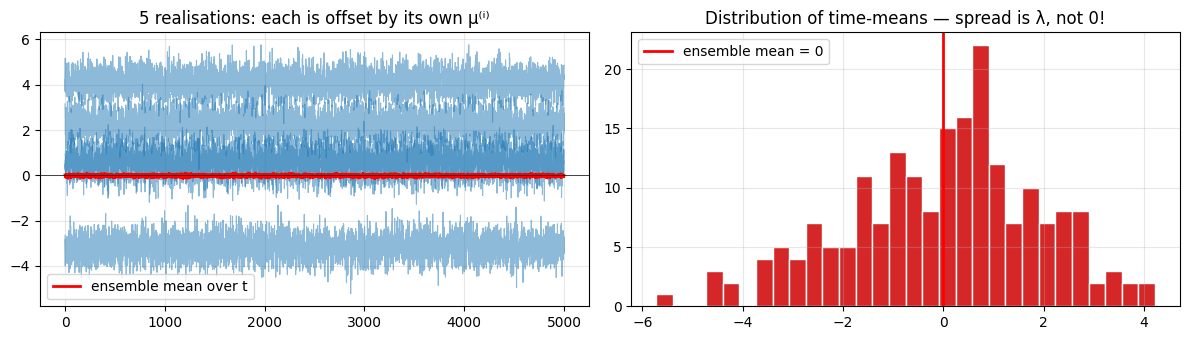

ensemble mean (avg over t) = -0.0188  (target: 0)
std of time-means          = 1.9228    (target ≈ λ = 2.0)


In [8]:
N, T, lam, sigma = 200, 5000, 2.0, 0.5
mu_per_realisation = rng.normal(scale=lam, size=N)
noise = rng.normal(scale=sigma, size=(N, T))
non_ergodic = mu_per_realisation[:, None] + noise

ens_mean_t = non_ergodic.mean(axis=0)
time_means = non_ergodic.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for i in range(5):
    axes[0].plot(non_ergodic[i], alpha=0.5, lw=0.8, color='C0')
axes[0].plot(ens_mean_t, color='red', lw=2, label='ensemble mean over t')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('5 realisations: each is offset by its own μ⁽ⁱ⁾')
axes[0].legend()

axes[1].hist(time_means, bins=30, color='C3', edgecolor='white')
axes[1].axvline(0, color='red', lw=2, label='ensemble mean = 0')
axes[1].set_title('Distribution of time-means — spread is λ, not 0!')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"ensemble mean (avg over t) = {ens_mean_t.mean():+.4f}  (target: 0)")
print(f"std of time-means          = {time_means.std():.4f}    (target ≈ λ = {lam})")


**Take-home:** ergodicity is what justifies *learning* statistics from one long realisation — without it, a single time series tells you about *itself*, not about the underlying process.


---

# Exercises

Try each one yourself before peeking at the solution. They should each take ~10–20 minutes.


## Exercise 1 — Stationarity classifier

Below are six time series. For each one:
1. Plot it.
2. Apply your `stationarity_report` function.
3. Decide whether it is stationary.

A series might fail stationarity for different reasons — drifting mean, drifting variance, periodicity, … — so identify which condition fails when applicable.


In [9]:
T = 400
series_dict = {
    'A': rng.normal(size=T),                                              # white noise
    'B': np.cumsum(rng.normal(size=T)),                                   # random walk
    'C': 0.05 * np.arange(T) + rng.normal(size=T),                        # trend
    'D': np.sin(2*np.pi*np.arange(T)/30) + rng.normal(scale=0.3, size=T), # periodic + noise
    'E': simulate_ar1(0.5, T, rng=rng).ravel(),                           # AR(1)
    'F': rng.normal(size=T) * (1 + np.arange(T)/T*3),                     # heteroscedastic
}

# Your code here: visualise + test each series


### Solution


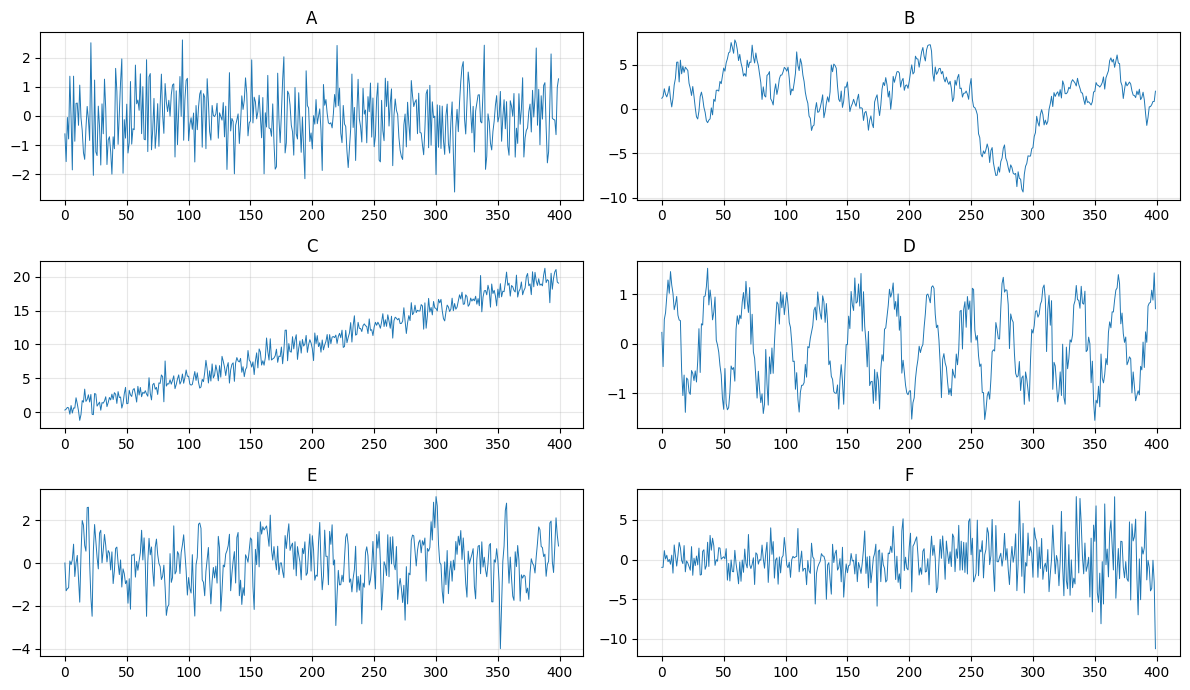

Stationarity test results:
----------------------------------------------------------------------
             A  ADF p=0.0000  KPSS p=0.1000  ->  stationary
             B  ADF p=0.0488  KPSS p=0.0395  ->  NON-stationary
             C  ADF p=0.9425  KPSS p=0.0100  ->  NON-stationary
             D  ADF p=0.0000  KPSS p=0.1000  ->  stationary
             E  ADF p=0.0000  KPSS p=0.1000  ->  stationary
             F  ADF p=0.0019  KPSS p=0.1000  ->  stationary

Interpretation:
  A : white noise -> stationary (constant mean & var, no autocorrelation)
  B : random walk -> NON-stationary (variance grows with t)
  C : trend       -> NON-stationary (mean drifts up)
  D : periodic+ε  -> stationary in the *weak* sense (mean & autocov
                     do not depend on t — only on lag)
  E : AR(1) φ<1   -> stationary
  F : hetero      -> NON-stationary (variance grows with t even though mean doesn't)


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))
for ax, (name, s) in zip(axes.ravel(), series_dict.items()):
    ax.plot(s, lw=0.7); ax.set_title(name)
plt.tight_layout(); plt.show()

print("Stationarity test results:")
print("-" * 70)
for name, s in series_dict.items():
    stationarity_report(s, name)

print()
print("Interpretation:")
print("  A : white noise -> stationary (constant mean & var, no autocorrelation)")
print("  B : random walk -> NON-stationary (variance grows with t)")
print("  C : trend       -> NON-stationary (mean drifts up)")
print("  D : periodic+ε  -> stationary in the *weak* sense (mean & autocov")
print("                     do not depend on t — only on lag)")
print("  E : AR(1) φ<1   -> stationary")
print("  F : hetero      -> NON-stationary (variance grows with t even though mean doesn't)")


## Exercise 2 — Make a non-stationary series stationary

The classical fix for trends and unit roots is **differencing**:
$$\nabla y_t = y_t - y_{t-1}.$$

Take series **B** (random walk) and series **C** (linear trend + noise) from Exercise 1. Apply differencing, plot the differenced series, and re-run `stationarity_report`. Do they become stationary? Comment on what happens to the original *signal* — does differencing destroy useful information?


### Solution

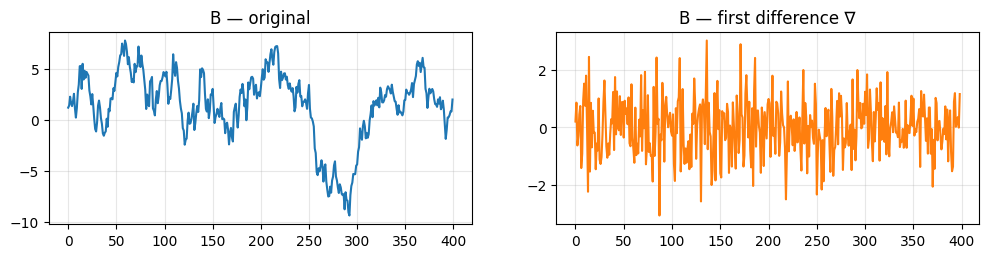

             B  ADF p=0.0488  KPSS p=0.0395  ->  NON-stationary
            ∇B  ADF p=0.0000  KPSS p=0.1000  ->  stationary



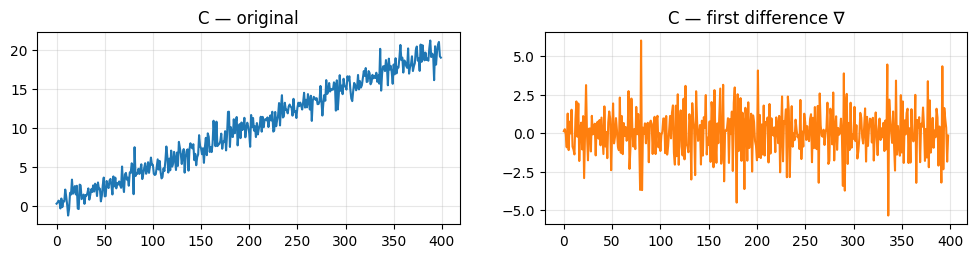

             C  ADF p=0.9425  KPSS p=0.0100  ->  NON-stationary
            ∇C  ADF p=0.0000  KPSS p=0.1000  ->  stationary

Notes:
  - The first difference of the random walk is plain Gaussian noise — perfectly stationary.
  - The first difference of (trend + noise) becomes white noise + a small constant offset.
  - Differencing destroys absolute level information — you can recover the original
    only by integrating *and* knowing y_0. That's why ARIMA(p, d, q) tracks d explicitly.


In [11]:
def diff(x, d=1):
    """d-th order differencing."""
    out = np.asarray(x, dtype=float).copy()
    for _ in range(d):
        out = out[1:] - out[:-1]
    return out

for name in ['B', 'C']:
    orig = series_dict[name]
    d1 = diff(orig)
    fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
    axes[0].plot(orig); axes[0].set_title(f'{name} — original')
    axes[1].plot(d1, color='C1');  axes[1].set_title(f'{name} — first difference ∇')
    plt.show()
    stationarity_report(orig, name)
    stationarity_report(d1,   f'∇{name}')
    print()

print("Notes:")
print("  - The first difference of the random walk is plain Gaussian noise — perfectly stationary.")
print("  - The first difference of (trend + noise) becomes white noise + a small constant offset.")
print("  - Differencing destroys absolute level information — you can recover the original")
print("    only by integrating *and* knowing y_0. That's why ARIMA(p, d, q) tracks d explicitly.")


## Exercise 3 — CLT for an M-dependent process

The CLT requires i.i.d. samples, but a weaker version holds for **M-dependent** sequences:
observations more than M apart are independent.

Construct an MA(2) process
$$y_t = \varepsilon_t + 0.7 \varepsilon_{t-1} + 0.4 \varepsilon_{t-2}, \quad \varepsilon_t \sim \mathcal{N}(0, 1).$$

This is **2-dependent** (any two samples ≥ 3 lags apart are independent).
1. Compute the sample mean of many independent realisations.
2. Plot the histogram of those sample means.
3. Compare to a theoretical Gaussian with mean 0 and variance $\sigma_{\bar y}^2$ predicted by the long-run variance $\sum_{j=-\infty}^{\infty} \gamma^j = \sigma^2 (1 + 0.7 + 0.4)^2$.


### Solution

Empirical std of sample means : 0.06628
Theoretical std (long-run var): 0.06641


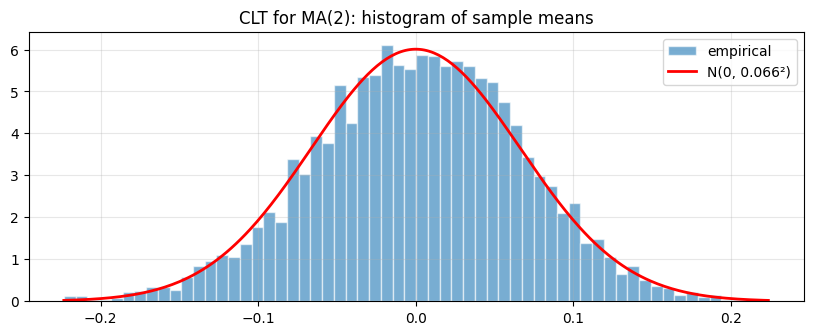


Take-home:
  - The CLT still holds; it just needs to use the *long-run* variance,
    not the per-sample variance σ². For positively-correlated processes
    long-run var > σ², so the sample mean is *less precise* than the
    naive iid formula would predict — a fundamental warning about
    fitting standard tools to dependent data.


In [12]:
def ma2(T, theta1=0.7, theta2=0.4, rng=None):
    rng = rng or np.random.default_rng()
    eps = rng.normal(size=T+2)
    return eps[2:] + theta1*eps[1:-1] + theta2*eps[:-2]

T_each = 1000
N_realisations = 5000
sample_means = np.array([ma2(T_each, rng=rng).mean() for _ in range(N_realisations)])

# Long-run variance: sum of all autocovariances
# For MA(2): gamma_0 = 1 + theta1^2 + theta2^2
#           gamma_1 = theta1 + theta1*theta2
#           gamma_2 = theta2
#           gamma_j = 0 for |j|>2
theta1, theta2 = 0.7, 0.4
gamma_0 = 1 + theta1**2 + theta2**2
gamma_1 = theta1 + theta1*theta2
gamma_2 = theta2
long_run_var = gamma_0 + 2*gamma_1 + 2*gamma_2  # equivalently (1 + theta1 + theta2)**2

theoretical_std = np.sqrt(long_run_var / T_each)

print(f"Empirical std of sample means : {sample_means.std():.5f}")
print(f"Theoretical std (long-run var): {theoretical_std:.5f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(sample_means, bins=60, density=True, alpha=0.6, color='C0', edgecolor='white',
        label='empirical')
xs = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, scale=theoretical_std), 'r-', lw=2,
        label=f'N(0, {theoretical_std:.3f}²)')
ax.set_title('CLT for MA(2): histogram of sample means'); ax.legend()
plt.show()

print()
print("Take-home:")
print("  - The CLT still holds; it just needs to use the *long-run* variance,")
print("    not the per-sample variance σ². For positively-correlated processes")
print("    long-run var > σ², so the sample mean is *less precise* than the")
print("    naive iid formula would predict — a fundamental warning about")
print("    fitting standard tools to dependent data.")


---

## Recap

| Concept | Key formula | Lecture page |
|---------|-------------|--------------|
| Time series | $S = \{s_1, \dots, s_T\}$, $s_i \in \mathbb{R}^d$ | 4 |
| Stochastic process | $\{X_t\}_{t \in T}$ — family of RVs | 4 |
| Mean | $\mu_t = E[X_t]$ | 5 |
| Autocovariance | $\gamma^j_t = E[(X_t - \mu_t)(X_{t-j} - \mu_{t-j})]$ | 5 |
| Weak stationarity | $\mu_t = \mu, \gamma^j_t = \gamma^j \;\forall t$ | 5 |
| Ergodicity | time average → ensemble average | 5 |
| Long-run variance | $\sum_j \gamma^j$ — drives the CLT for dependent data | 5 |

**Next:** Lecture 2 covers the broader ML pipeline for time series — train/val/test splits that respect time order, walk-forward CV, and the linear regression baseline.
